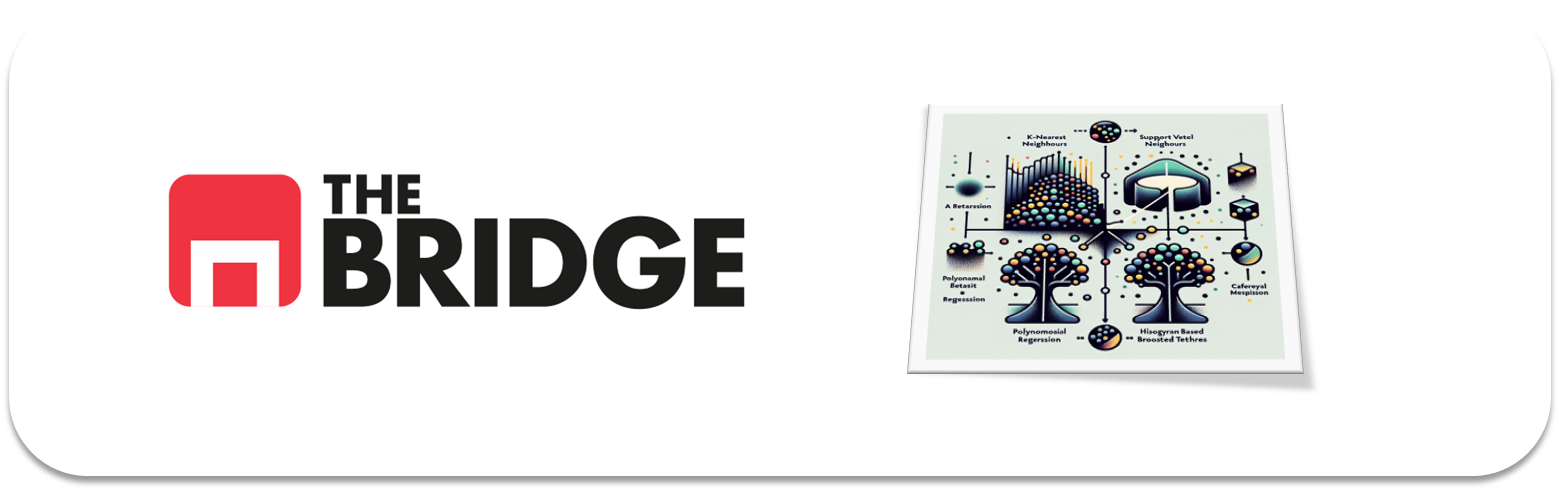

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [4]:
df = pd.read_csv("./data/credit_npo.csv")

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [5]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


Descripción de variables

- SeriousDlqin2yrs
Variable objetivo del modelo. Indica si el cliente ha tenido un evento serio de morosidad en los últimos dos años.

    1 → el cliente tuvo dificultades financieras

    0 → el cliente no tuvo dificultades financieras.

- RevolvingUtilizationOfUnsecuredLines
Proporción del crédito revolving utilizado respecto al crédito total disponible. Valores altos indican un mayor uso del crédito disponible.

- age
Edad del cliente en años.

- NumberOfTime30-59DaysPastDueNotWorse
Número de veces que el cliente ha tenido retrasos de entre 30 y 59 días en sus pagos.

- DebtRatio
Ratio de deuda. Representa la proporción de pagos de deuda respecto a los ingresos del cliente.

- MonthlyIncome
Ingresos mensuales del cliente.

- NumberOfOpenCreditLinesAndLoans
Número total de líneas de crédito abiertas, incluyendo tarjetas y préstamos personales.

- NumberOfTimes90DaysLate
Número de veces que el cliente ha tenido retrasos superiores a 90 días en los pagos.

- NumberRealEstateLoansOrLines
Número de préstamos o líneas de crédito relacionadas con bienes inmuebles.

- NumberOfTime60-89DaysPastDueNotWorse
Número de veces que el cliente se ha retrasado entre 60 y 89 días en sus pagos.

- NumberOfDependents
Número de personas dependientes económicamente del cliente.

Clasificación inicial de variables

- Variable objetivo

    SeriousDlqin2yrs (variable binaria)

    Variables numéricas continuas

    RevolvingUtilizationOfUnsecuredLines

    DebtRatio

    MonthlyIncome

    age

- Variables numéricas discretas

    NumberOfTime30-59DaysPastDueNotWorse

    NumberOfTimes90DaysLate

    NumberOfOpenCreditLinesAndLoans

    NumberRealEstateLoansOrLines

    NumberOfTime60-89DaysPastDueNotWorse

    NumberOfDependents

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

El problema planteado es un problema de clasificación binaria, ya que el objetivo es predecir si un cliente tendrá o no dificultades financieras en los próximos dos años.

La variable objetivo es SeriousDlqin2yrs, que toma dos valores posibles:

    1 → el cliente presenta morosidad o problemas financieros

    0 → el cliente no presenta problemas financieros.

### #1.3
Pinta la distribución de frecuencias del target y coméntala

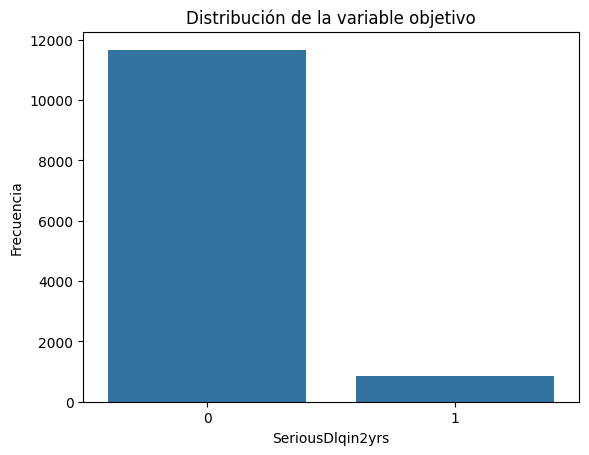

In [7]:
target = "SeriousDlqin2yrs"

sns.countplot(x=df[target])

plt.title("Distribución de la variable objetivo")
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Frecuencia")

plt.show()

La distribución de la variable objetivo muestra un fuerte desbalance entre clases. La mayoría de los registros pertenecen a la clase 0 (clientes sin problemas financieros), mientras que la clase 1 representa una proporción mucho menor del dataset.

Este desbalance puede afectar al rendimiento de los modelos de clasificación, ya que podrían tender a predecir mayoritariamente la clase dominante. Por este motivo, será necesario aplicar técnicas de balanceo como SMOTE o undersampling para mejorar la capacidad del modelo para detectar la clase minoritaria.

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

Lista de variables numéricas

In [20]:
num_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
    "NumberOfTime30-59DaysPastDueNotWorse"
]

(10, 2)


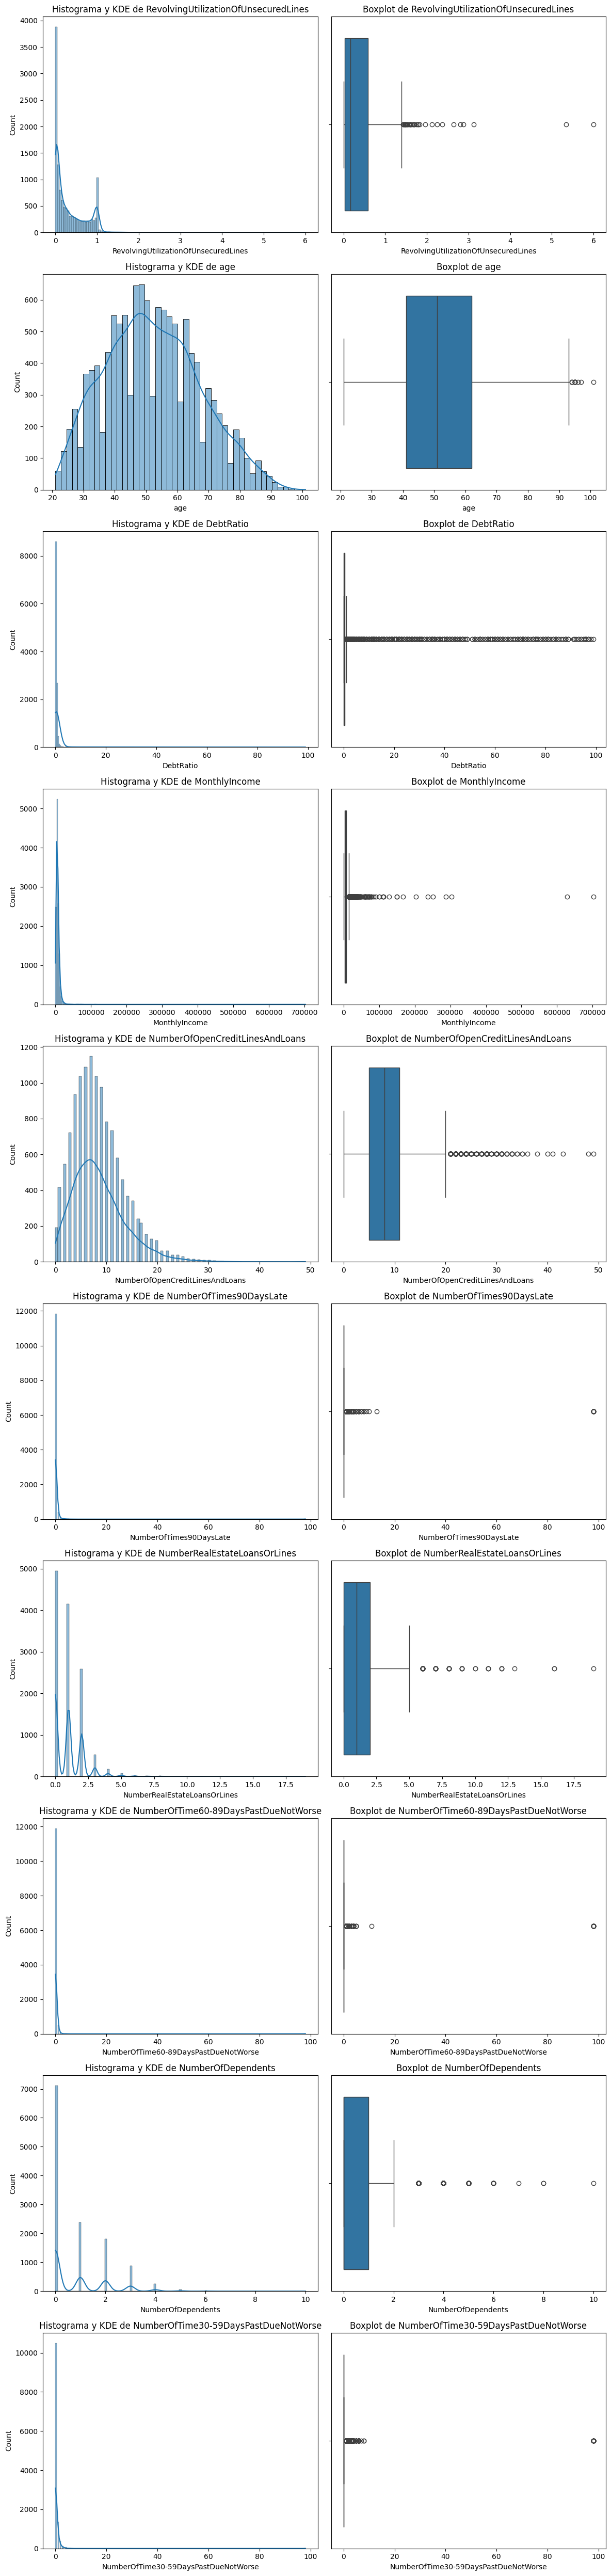

In [21]:
bt.plot_combined_graphs(df, num_cols)

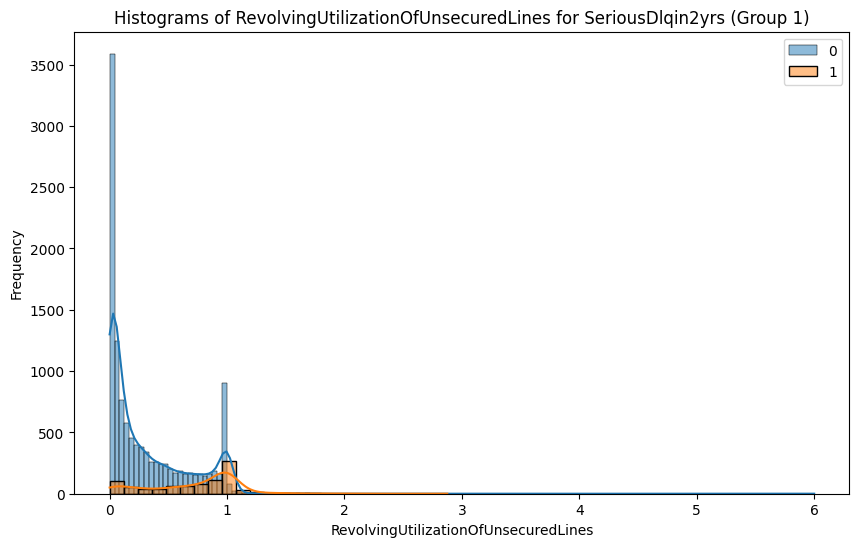

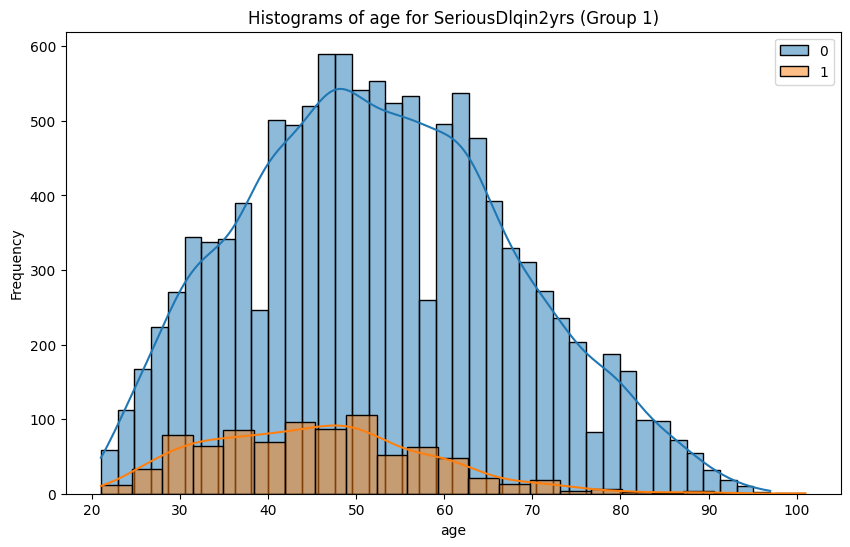

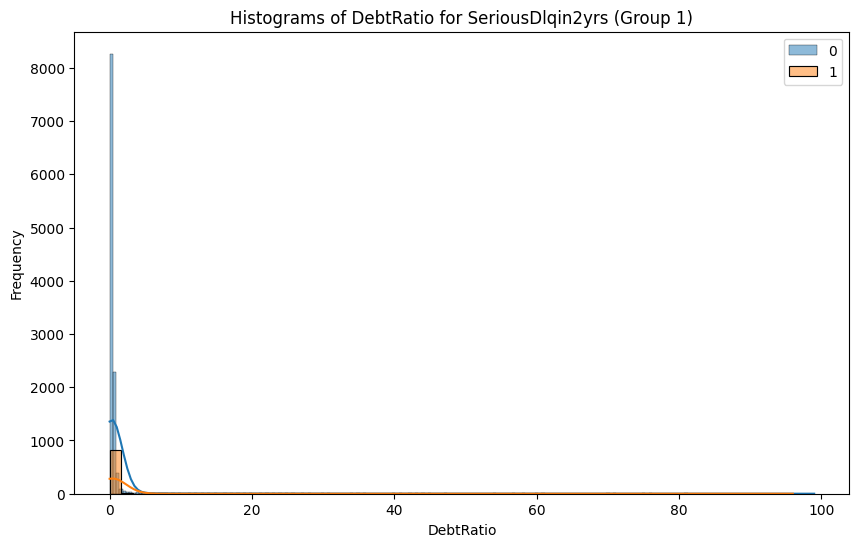

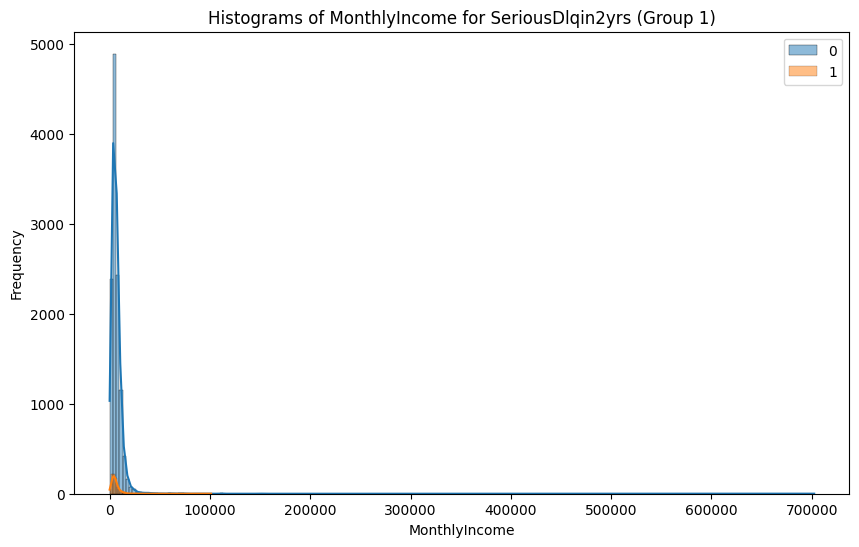

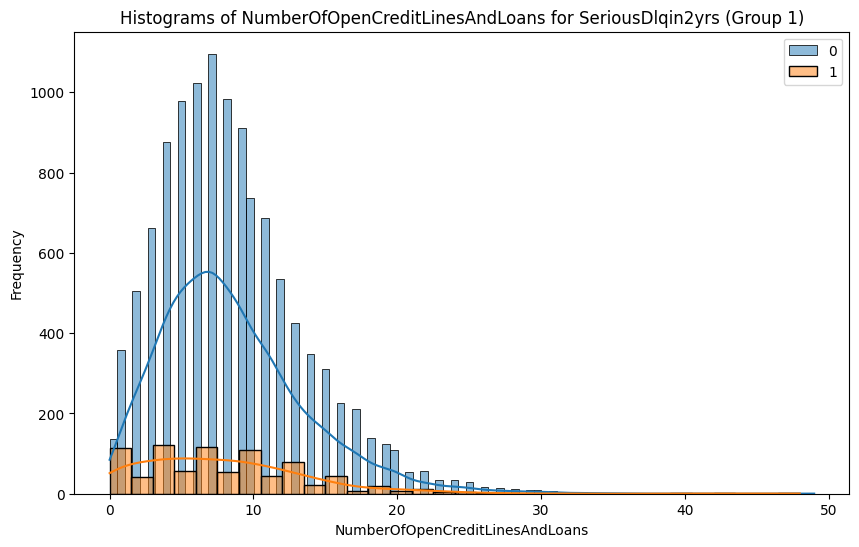

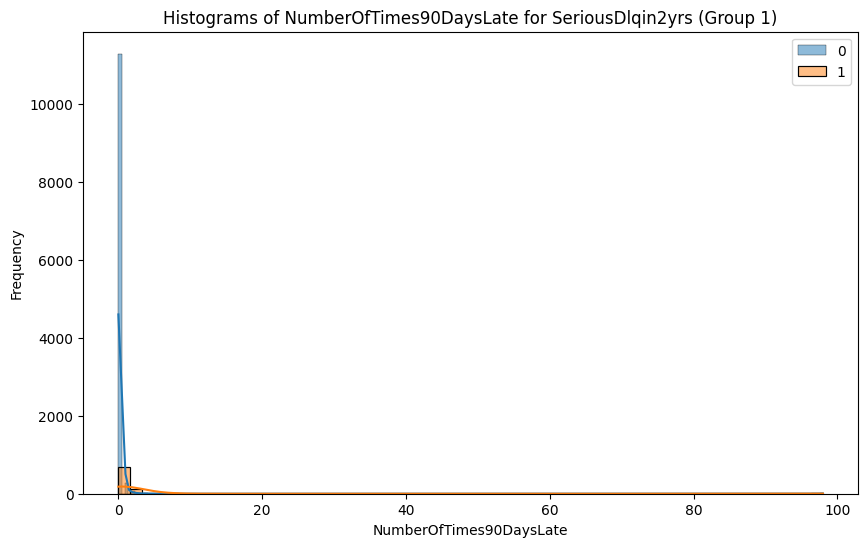

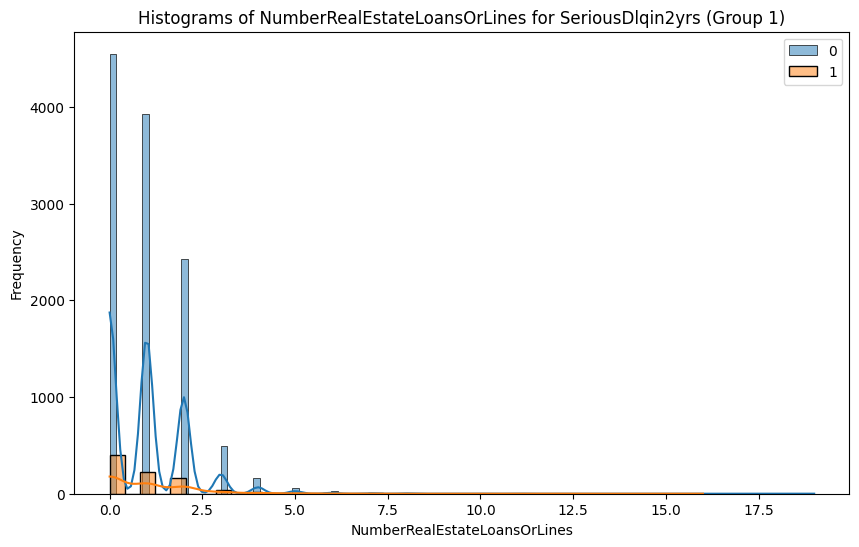

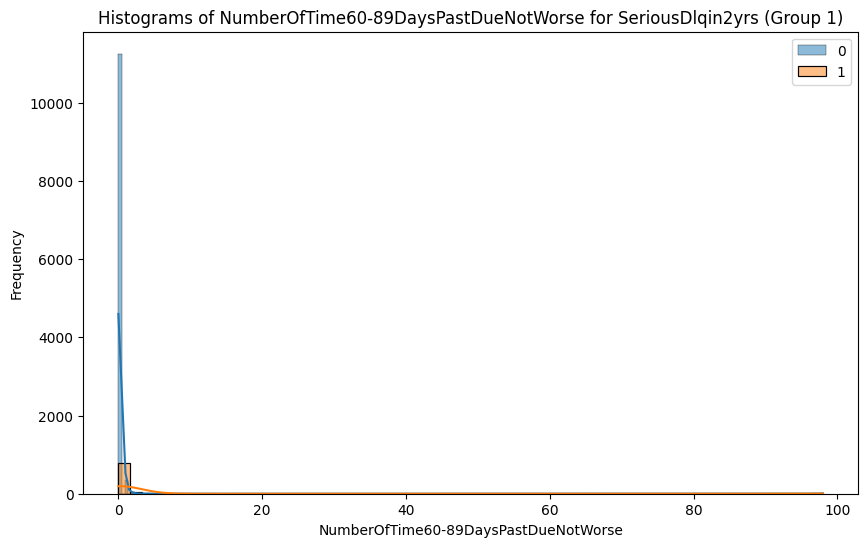

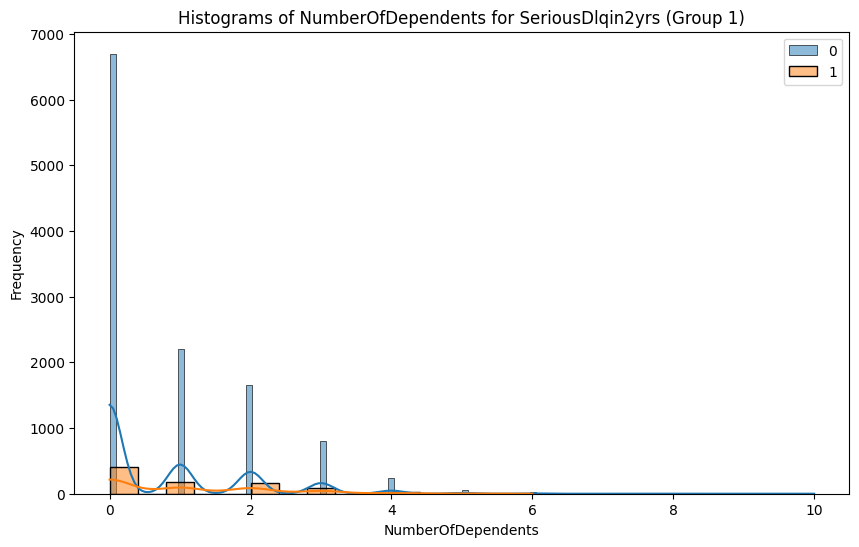

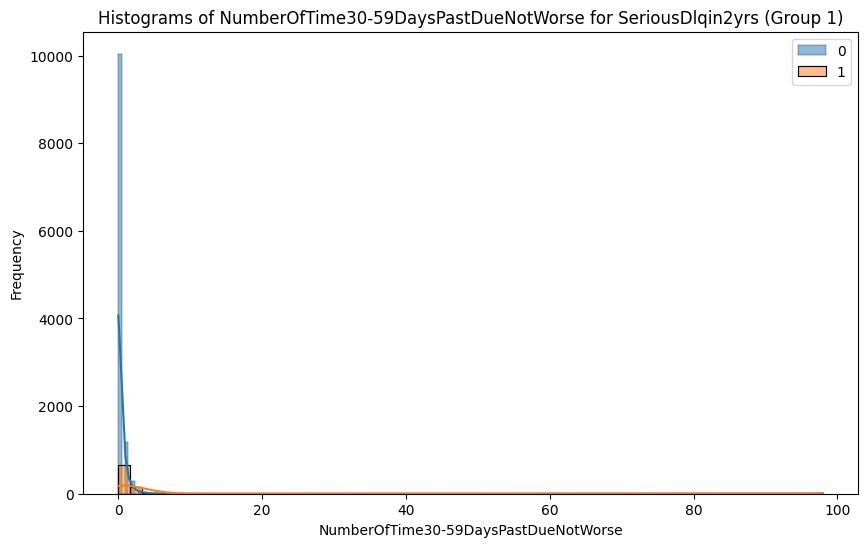

In [22]:
target = "SeriousDlqin2yrs"

for col in num_cols:
    bt.plot_grouped_histograms(df, target, col, 2)

Tratamiento de valores nulos

In [8]:
df.isna().sum()

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

In [9]:
df["NumberOfDependents"].fillna(df["NumberOfDependents"].mode()[0], inplace=True)

df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)

C:\Users\andre\AppData\Local\Temp\ipykernel_25512\1925893468.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["NumberOfDependents"].fillna(df["NumberOfDependents"].mode()[0], inplace=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_25512\1925893468.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

Train Test Split

In [10]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Transformación logarítmica

In [11]:
for col in X_train.columns:
    if col != "age":
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

Escalado

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Entrenamiento de modelos

In [13]:
models = {
    "Logistic": LogisticRegression(max_iter=10000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():

    if name == "KNN":
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="balanced_accuracy")
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="balanced_accuracy")

    print(name, "Balanced accuracy:", scores.mean())

Logistic Balanced accuracy: 0.5584969202784752
KNN Balanced accuracy: 0.5746678909259526
RandomForest Balanced accuracy: 0.5822605806016976


Balanceo con SMOTE

In [14]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote_scaled, y_train_smote_scaled = smote.fit_resample(X_train_scaled, y_train)

Evaluación con datos balanceados

In [15]:
for name, model in models.items():

    if name == "KNN":
        scores = cross_val_score(model, X_train_smote_scaled, y_train_smote_scaled, cv=5, scoring="balanced_accuracy")
    else:
        scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="balanced_accuracy")

    print(name, "Balanced accuracy:", scores.mean())

Logistic Balanced accuracy: 0.7762379442796042
KNN Balanced accuracy: 0.9061901514986428
RandomForest Balanced accuracy: 0.9543293068269012


Ajuste de hiperparámetros

In [16]:
param_grid = {
    "n_neighbors":[5,7,9],
    "weights":["uniform","distance"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="balanced_accuracy"
)

grid.fit(X_train_scaled, y_train)

grid.best_params_

{'n_neighbors': 5, 'weights': 'distance'}

Evaluación final

In [17]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2335
           1       0.44      0.18      0.26       173

    accuracy                           0.93      2508
   macro avg       0.69      0.58      0.61      2508
weighted avg       0.91      0.93      0.91      2508



Confusion Matrix

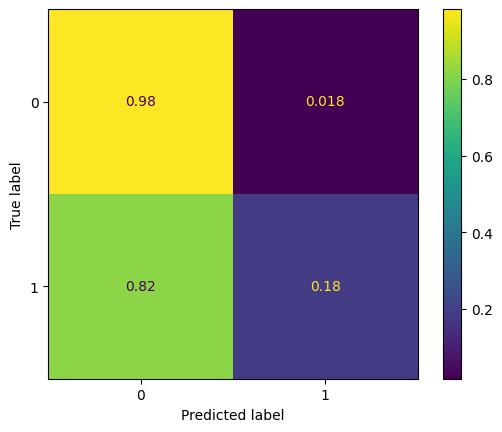

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true"
)

plt.show()